In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import japanize_matplotlib

In [16]:
FILE_PATH = "week3_type_classification_re24_wpa.csv"

type_df = pd.read_csv(FILE_PATH, encoding="utf-8-sig")

print("データ行数:", len(type_df))
print("列名一覧:")
print(type_df.columns.tolist())

type_df.head()

データ行数: 25
列名一覧:
['球団', '打者名', 'PA', '打点合計', 'RE24合計', 'WPA合計', '打点/PA', 'RE24/PA', 'WPA/PA', '打点順位', 'RE24順位', 'WPA順位', '打点/PA順位', 'RE24/PA順位', 'WPA/PA順位', 'WPA評価上昇', 'タイプ']


,球団,打者名,PA,打点合計,RE24合計,WPA合計,打点/PA,RE24/PA,WPA/PA,打点順位,RE24順位,WPA順位,打点/PA順位,RE24/PA順位,WPA/PA順位,WPA評価上昇,タイプ
0,阪神,佐藤 輝明,544,91,47.723,3.238965,0.167279,0.087726,0.005954,1,1,6,4,4,10,-5,総合型
1,西武,ネビン,491,54,21.654,0.468037,0.109980,0.044102,0.000953,2,5,18,13,11,19,-16,得点貢献型
2,中日,細川 成也,313,43,19.930,3.654191,0.137380,0.063674,0.011675,5,6,5,8,8,5,0,総合型
3,オリックス,杉本 裕太郎,308,29,-8.236,0.965217,0.094156,-0.026740,0.003134,10,25,13,20,22,15,-3,勝利貢献型
4,ソフトバンク,山川 穂高,289,35,0.287,0.849737,0.121107,0.000993,0.002940,8,18,14,10,18,16,-6,その他


In [17]:
type_count = type_df["タイプ"].value_counts().reset_index()
type_count.columns = ["タイプ", "人数"]

type_count

,タイプ,人数
0,その他,11
1,総合型,7
2,勝利貢献型,4
3,得点貢献型,3


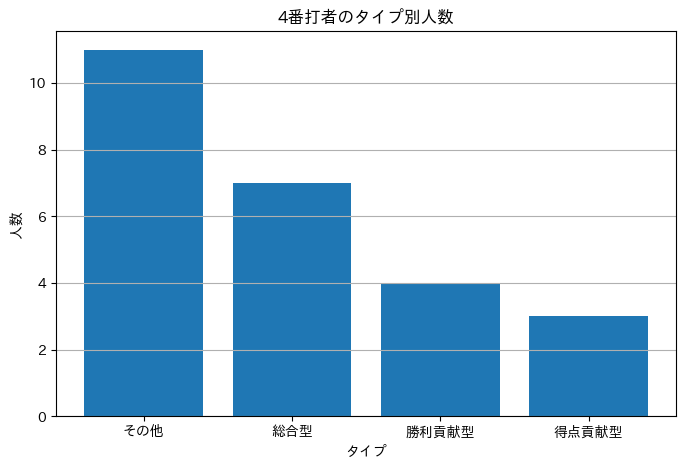

In [18]:
plt.figure(figsize=(8, 5))

plt.bar(type_count["タイプ"], type_count["人数"])

plt.xlabel("タイプ")
plt.ylabel("人数")
plt.title("4番打者のタイプ別人数")
plt.grid(axis="y")
plt.show()

In [19]:
type_summary = (
    type_df.groupby("タイプ")
    .agg(
        人数=("タイプ", "count"),
        平均PA=("PA", "mean"),
        平均打点=("打点合計", "mean"),
        平均RE24=("RE24合計", "mean"),
        平均WPA=("WPA合計", "mean"),
        平均打点_PA=("打点/PA", "mean"),
        平均RE24_PA=("RE24/PA", "mean"),
        平均WPA_PA=("WPA/PA", "mean"),
        平均打点順位=("打点順位", "mean"),
        平均RE24順位=("RE24順位", "mean"),
        平均WPA順位=("WPA順位", "mean")
    )
    .reset_index()
)

type_summary

,タイプ,人数,平均PA,平均打点,平均RE24,平均WPA,平均打点_PA,平均RE24_PA,平均WPA_PA,平均打点順位,平均RE24順位,平均WPA順位
0,その他,11,180.363636,17.818182,0.469364,-0.119365,0.094948,0.002355,-0.001445,17.545455,17.818182,18.090909
1,勝利貢献型,4,237.250000,23.500000,-0.271000,2.185736,0.099253,-0.000261,0.009494,12.500000,18.500000,8.000000
2,得点貢献型,3,304.000000,37.000000,14.272000,0.270562,0.123394,0.050491,0.001130,9.000000,7.000000,19.000000
3,総合型,7,257.285714,44.857143,24.677429,3.258178,0.178911,0.099435,0.014488,6.571429,4.857143,5.285714


In [20]:
general_players = type_df[type_df["タイプ"] == "総合型"].sort_values(
    ["RE24順位", "WPA順位"]
)

general_players[
    ["球団", "打者名", "PA", "打点合計", "RE24合計", "WPA合計",
     "RE24順位", "WPA順位", "RE24/PA", "WPA/PA", "タイプ"]
]

,球団,打者名,PA,打点合計,RE24合計,WPA合計,RE24順位,WPA順位,RE24/PA,WPA/PA,タイプ
0,阪神,佐藤 輝明,544,91,47.723,3.238965,1,6,0.087726,0.005954,総合型
9,ヤクルト,村上 宗隆,222,47,31.171,4.020346,2,4,0.140410,0.018110,総合型
5,巨人,岡本 和真,280,49,28.686,4.366410,3,3,0.102450,0.015594,総合型
17,日本ハム,レイエス,157,40,25.210,4.825634,4,2,0.160573,0.030737,総合型
2,中日,細川 成也,313,43,19.930,3.654191,6,5,0.063674,0.011675,総合型
16,巨人,キャベッジ,157,26,10.538,1.219419,8,9,0.067121,0.007767,総合型
22,ソフトバンク,近藤 健介,128,18,9.484,1.482278,10,8,0.074094,0.011580,総合型


In [21]:
score_players = type_df[type_df["タイプ"] == "得点貢献型"].sort_values(
    "RE24順位"
)

score_players[
    ["球団", "打者名", "PA", "打点合計", "RE24合計", "WPA合計",
     "RE24順位", "WPA順位", "RE24/PA", "WPA/PA", "タイプ"]
]

,球団,打者名,PA,打点合計,RE24合計,WPA合計,RE24順位,WPA順位,RE24/PA,WPA/PA,タイプ
1,西武,ネビン,491,54,21.654,0.468037,5,18,0.044102,0.000953,得点貢献型
7,広島,末包 昇大,267,40,10.932,-0.075041,7,20,0.040944,-0.000281,得点貢献型
18,楽天,ボイト,154,17,10.230,0.418691,9,19,0.066429,0.002719,得点貢献型


In [22]:
win_players = type_df[type_df["タイプ"] == "勝利貢献型"].sort_values(
    "WPA順位"
)

win_players[
    ["球団", "打者名", "PA", "打点合計", "RE24合計", "WPA合計",
     "RE24順位", "WPA順位", "RE24/PA", "WPA/PA", "タイプ"]
]

,球団,打者名,PA,打点合計,RE24合計,WPA合計,RE24順位,WPA順位,RE24/PA,WPA/PA,タイプ
8,DeNA,牧 秀悟,243,27,8.321,5.049012,12,1,0.034243,0.020778,勝利貢献型
13,広島,モンテロ,180,18,-3.287,1.595811,20,7,-0.018261,0.008866,勝利貢献型
10,日本ハム,野村 佑希,218,20,2.118,1.132902,17,11,0.009716,0.005197,勝利貢献型
3,オリックス,杉本 裕太郎,308,29,-8.236,0.965217,25,13,-0.026740,0.003134,勝利貢献型


In [23]:
other_players = type_df[type_df["タイプ"] == "その他"].sort_values(
    ["RE24順位", "WPA順位"]
)

other_players[
    ["球団", "打者名", "PA", "打点合計", "RE24合計", "WPA合計",
     "RE24順位", "WPA順位", "RE24/PA", "WPA/PA", "タイプ"]
]

,球団,打者名,PA,打点合計,RE24合計,WPA合計,RE24順位,WPA順位,RE24/PA,WPA/PA,タイプ
21,日本ハム,郡司 裕也,148,14,9.203,0.776498,11,15,0.062182,0.005247,その他
11,DeNA,オースティン,210,26,5.493,1.218329,13,10,0.026157,0.005802,その他
24,楽天,黒川 史陽,105,11,5.203,1.124762,14,12,0.049552,0.010712,その他
15,ソフトバンク,中村 晃,171,17,3.365,0.678367,15,17,0.019678,0.003967,その他
6,ヤクルト,オスナ,273,30,3.214,0.736590,16,16,0.011773,0.002698,その他
4,ソフトバンク,山川 穂高,289,35,0.287,0.849737,18,14,0.000993,0.002940,その他
14,ロッテ,ソト,179,18,-1.956,-0.638764,19,21,-0.010927,-0.003569,その他
23,楽天,フランコ,108,8,-4.178,-1.740724,21,24,-0.038685,-0.016118,その他
20,中日,ボスラー,150,13,-4.350,-1.352659,22,23,-0.029000,-0.009018,その他
12,ロッテ,山本 大斗,201,18,-4.906,-0.718523,23,22,-0.024408,-0.003575,その他


In [24]:
representative_players = pd.concat([
    general_players.head(3),
    score_players.head(3),
    win_players.head(3)
])

representative_players[
    ["球団", "打者名", "PA", "打点合計", "RE24合計", "WPA合計",
     "RE24順位", "WPA順位", "RE24/PA", "WPA/PA", "タイプ"]
]

,球団,打者名,PA,打点合計,RE24合計,WPA合計,RE24順位,WPA順位,RE24/PA,WPA/PA,タイプ
0,阪神,佐藤 輝明,544,91,47.723,3.238965,1,6,0.087726,0.005954,総合型
9,ヤクルト,村上 宗隆,222,47,31.171,4.020346,2,4,0.140410,0.018110,総合型
5,巨人,岡本 和真,280,49,28.686,4.366410,3,3,0.102450,0.015594,総合型
1,西武,ネビン,491,54,21.654,0.468037,5,18,0.044102,0.000953,得点貢献型
7,広島,末包 昇大,267,40,10.932,-0.075041,7,20,0.040944,-0.000281,得点貢献型
18,楽天,ボイト,154,17,10.230,0.418691,9,19,0.066429,0.002719,得点貢献型
8,DeNA,牧 秀悟,243,27,8.321,5.049012,12,1,0.034243,0.020778,勝利貢献型
13,広島,モンテロ,180,18,-3.287,1.595811,20,7,-0.018261,0.008866,勝利貢献型
10,日本ハム,野村 佑希,218,20,2.118,1.132902,17,11,0.009716,0.005197,勝利貢献型


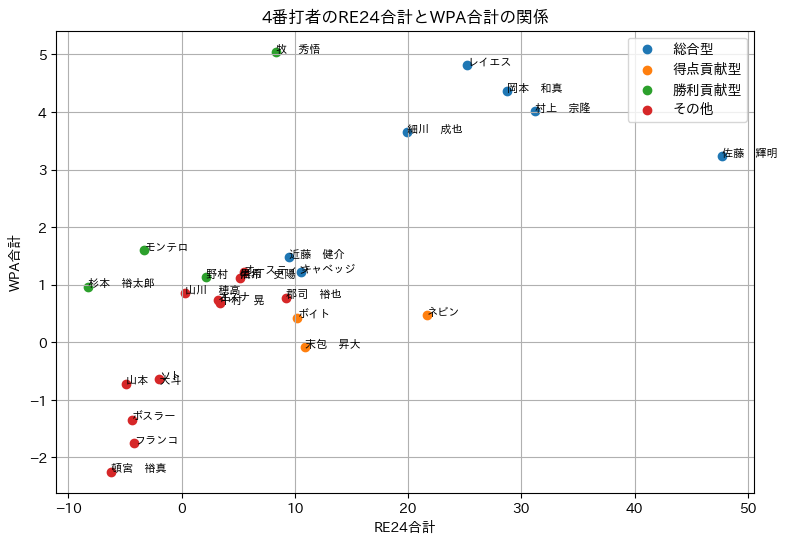

In [25]:
plt.figure(figsize=(9, 6))

for t in type_df["タイプ"].unique():
    data = type_df[type_df["タイプ"] == t]
    plt.scatter(data["RE24合計"], data["WPA合計"], label=t)

for _, row in type_df.iterrows():
    plt.text(row["RE24合計"], row["WPA合計"], row["打者名"], fontsize=8)

plt.xlabel("RE24合計")
plt.ylabel("WPA合計")
plt.title("4番打者のRE24合計とWPA合計の関係")
plt.legend()
plt.grid(True)
plt.show()

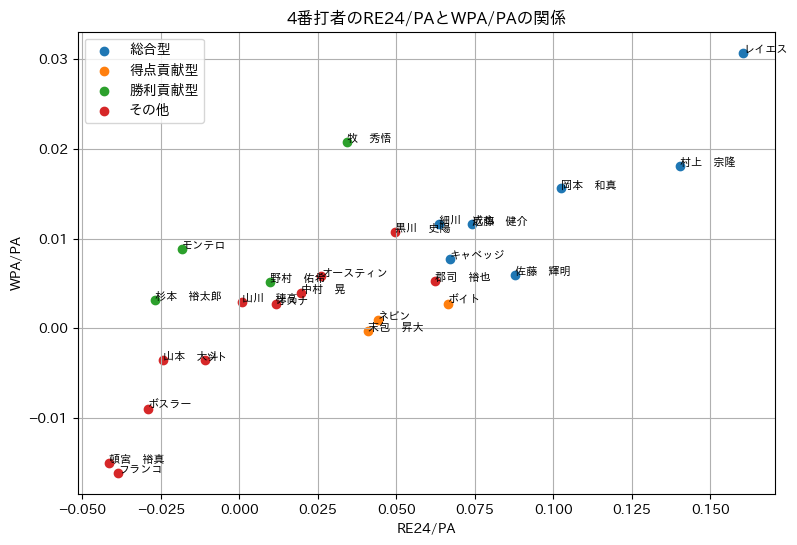

In [26]:
plt.figure(figsize=(9, 6))

for t in type_df["タイプ"].unique():
    data = type_df[type_df["タイプ"] == t]
    plt.scatter(data["RE24/PA"], data["WPA/PA"], label=t)

for _, row in type_df.iterrows():
    plt.text(row["RE24/PA"], row["WPA/PA"], row["打者名"], fontsize=8)

plt.xlabel("RE24/PA")
plt.ylabel("WPA/PA")
plt.title("4番打者のRE24/PAとWPA/PAの関係")
plt.legend()
plt.grid(True)
plt.show()

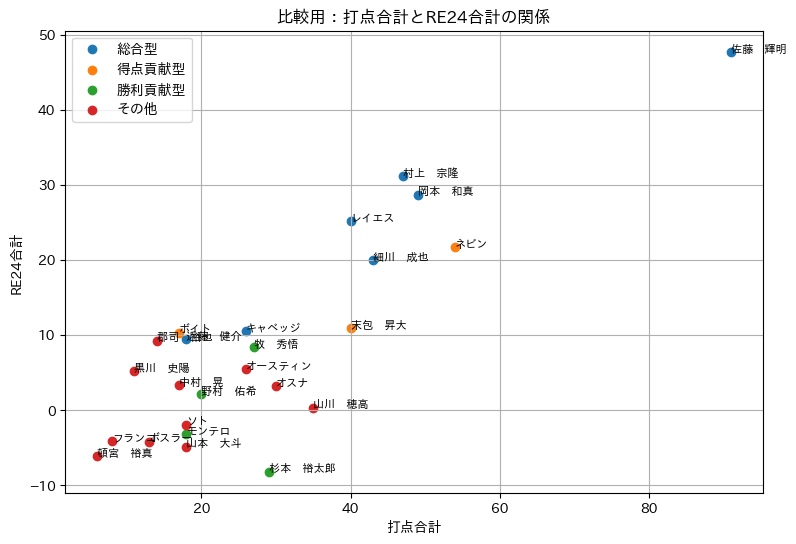

In [27]:
plt.figure(figsize=(9, 6))

for t in type_df["タイプ"].unique():
    data = type_df[type_df["タイプ"] == t]
    plt.scatter(data["打点合計"], data["RE24合計"], label=t)

for _, row in type_df.iterrows():
    plt.text(row["打点合計"], row["RE24合計"], row["打者名"], fontsize=8)

plt.xlabel("打点合計")
plt.ylabel("RE24合計")
plt.title("比較用：打点合計とRE24合計の関係")
plt.legend()
plt.grid(True)
plt.show()

In [28]:
graph_plan = pd.DataFrame({
    "グラフ": [
        "タイプ別人数",
        "RE24合計 × WPA合計",
        "RE24/PA × WPA/PA",
        "打点合計 × RE24合計"
    ],
    "使う目的": [
        "4番打者をどのタイプに分類できたか示す",
        "得点期待と勝利貢献の関係を示す",
        "起用数の差を考慮した効率を見る",
        "従来指標の打点とRE24の関係を見る"
    ],
    "発表での重要度": [
        "高",
        "最高",
        "高",
        "中"
    ]
})

graph_plan

,グラフ,使う目的,発表での重要度
0,タイプ別人数,4番打者をどのタイプに分類できたか示す,高
1,RE24合計 × WPA合計,得点期待と勝利貢献の関係を示す,最高
2,RE24/PA × WPA/PA,起用数の差を考慮した効率を見る,高
3,打点合計 × RE24合計,従来指標の打点とRE24の関係を見る,中
